In [22]:
import numpy as np
import ludics.main
import ludics.fitness_functions
import matplotlib.pyplot as plt

We consider the following parameter combinations:

$\alpha_i = i, r=\frac{N}{2}$

$\alpha_i = \frac{i}{2}, r=\frac{N}{2}$

$\alpha_i = i, r = 2N$

$\alpha_i = \frac{i}{2}, r=2N$

and look at $N \in (3,10)$

Take $\beta = 0.5$ and $\mu = 0.1$

In [137]:
def get_pc(N,r,alphas):
    state_space = ludics.main.get_state_space(N=N,k=2)

    transition_matrix = ludics.main.generate_transition_matrix(
        state_space=state_space,
        fitness_function=ludics.fitness_functions.heterogeneous_contribution_pgg_fitness_function,
        compute_transition_probability=ludics.main.compute_introspection_transition_probability,
        individual_to_action_mutation_probability=np.full(shape=(N,2), fill_value=0.1),
        contribution_vector=alphas,
        r=r,
        number_of_strategies=2,
        choice_intensity = 0.5
    )

    steady_state = ludics.main.approximate_steady_state(transition_matrix)

    pc = (steady_state @ state_space).sum() / N
    return pc


def get_vince_val(alphas, r, N):
    
    running_phis = []

    for i in range(N):
        numerator = 0.8
        denominator = 1 + np.exp(0.5 * (alphas[i] * (1 - (r/N))))

        running_phis.append((numerator / denominator) + 0.1)
    
    return sum(running_phis) / N

def get_pc_from_sims(alphas,r,N, seed):
    initial_state=np.array([0 for _ in range(N)])
    initial_state[1] = 1
    _, dict = ludics.main.simulate_markov_chain(initial_state=initial_state, number_of_strategies=2, fitness_function=ludics.fitness_functions.heterogeneous_contribution_pgg_fitness_function, compute_transition_probability=ludics.main.compute_introspection_transition_probability, individual_to_action_mutation_probability=np.full(shape=(N,2), fill_value=0.1), r=r, contribution_vector=alphas, warmup=100, iterations=10000, seed=seed, 
    choice_intensity=0.5)
    print(dict)
    per_state_pc = np.array([sum(key) * value / 10000 for key, value in dict.items()])

    sim_pc = np.sum(per_state_pc)/N
    return sim_pc


In [91]:
theoretic_vals_rlow_ahigh = []
vince_vals_rlow_ahigh = []
for N in range(3,11):

    theoretic_vals_rlow_ahigh.append(get_pc(N=N, r=N/2, alphas=np.array([i for i in range(N)])))

    vince_vals_rlow_ahigh.append(get_vince_val(alphas=np.array([i for i in range(N)]), r=N/2, N=N))

In [105]:
theoretic_vals_rlow_alow = []
vince_vals_rlow_alow = []
for N in range(3,11):

    theoretic_vals_rlow_alow.append(get_pc(N=N, r=N/2, alphas=np.array([np.log(i) for i in range(1,N+1)])))

    vince_vals_rlow_alow.append(get_vince_val(alphas=np.array([np.log(i) for i in range(1,N+1)]), r=N/2, N=N))

In [106]:
theoretic_vals_rhigh_alow = []
vince_vals_rhigh_alow = []
for N in range(3,11):

    theoretic_vals_rhigh_alow.append(get_pc(N=N, r=2*N, alphas=np.array([np.log(i) for i in range(1,N+1)])))

    vince_vals_rhigh_alow.append(get_vince_val(alphas=np.array([np.log(i) for i in range(1,N+1)]), r=2*N, N=N))

In [94]:
theoretic_vals_rhigh_ahigh = []
vince_vals_rhigh_ahigh = []
for N in range(3,11):

    theoretic_vals_rhigh_ahigh.append(get_pc(N=N, r=2*N, alphas=np.array([i for i in range(N)])))

    vince_vals_rhigh_ahigh.append(get_vince_val(alphas=np.array([i for i in range(N)]), r=2*N, N=N))

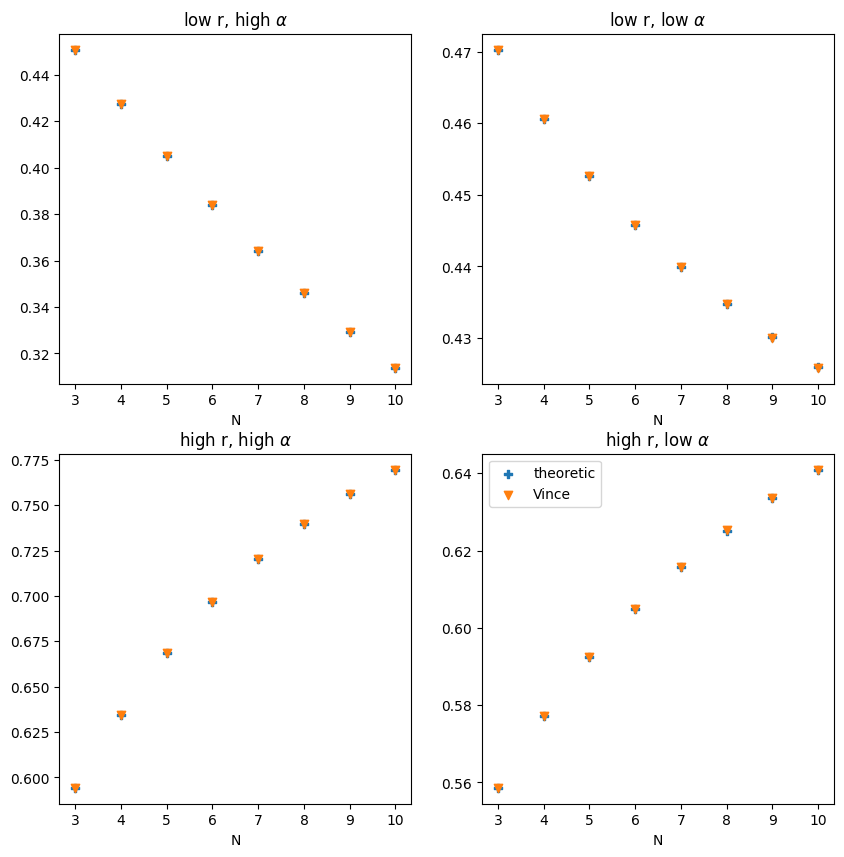

In [107]:
fig, axarray = plt.subplots(2,2, figsize=(10, 10))
ax = axarray.flatten()
ax[0].scatter(range(3,11), theoretic_vals_rlow_ahigh, label=r'theoretic', marker='P')
ax[0].scatter(range(3,11), vince_vals_rlow_ahigh, label=r'Vince', marker='v')
ax[0].set_xlabel("N")
ax[0].set_title(r"low r, high $\alpha$")

ax[1].scatter(range(3,11), theoretic_vals_rlow_alow, label=r'theoretic', marker='P')
ax[1].scatter(range(3,11), vince_vals_rlow_alow, label=r'Vince', marker='v')
ax[1].set_xlabel("N")
ax[1].set_title(r"low r, low $\alpha$")

ax[2].scatter(range(3,11), theoretic_vals_rhigh_ahigh, label=r'theoretic', marker='P')
ax[2].scatter(range(3,11), vince_vals_rhigh_ahigh, label=r'Vince', marker='v')
ax[2].set_xlabel("N")
ax[2].set_title(r"high r, high $\alpha$")

ax[3].scatter(range(3,11), theoretic_vals_rhigh_alow, label=r'theoretic', marker='P')
ax[3].scatter(range(3,11), vince_vals_rhigh_alow, label=r'Vince', marker='v')
ax[3].set_xlabel("N")
ax[3].set_title(r"high r, low $\alpha$")

plt.legend()
plt.show()

In [128]:
import seaborn as sns
simulation_vals = {}
vince_vals = []

for N in range(11, 100, 11):
    print(N)
    current_N = []
    alphas = np.array([i for i in range(1, N+1)])
    for seed in range(1,40):
        current_N.append(get_pc_from_sims(alphas=alphas, r=N/2, N=N, seed=seed))
    simulation_vals[N] = current_N
    vince_vals.append(get_vince_val(alphas=alphas, r=N/2, N=N))


11
22
33
44
55
66
77
88
99


<Axes: >

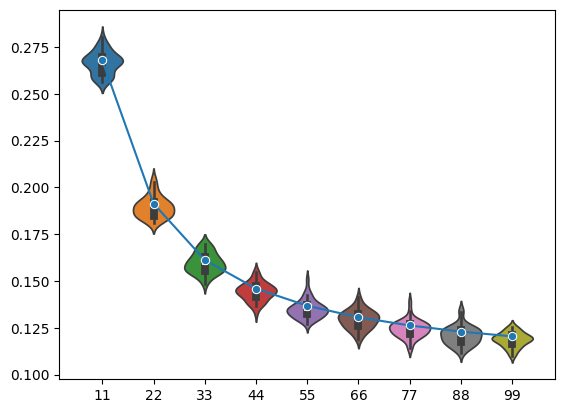

In [147]:
new_dict = {}
for key,value in simulation_vals.items():
    data = [value[i]/10000 for i in range(len(value))]
    new_dict[key]=data
sns.violinplot(data=new_dict)
sns.lineplot(x=range(len(new_dict)), y=vince_vals, marker='o')

[0.622459331201855 0.731058578630005 0.817574476193644 0.880797077977882
 0.924141819978757 0.952574126822433 0.970687769248644 0.982013790037908
 0.989013057369407 0.993307149075715 0.995929862284104 0.997527376843365
 0.998498817743263 0.999088948805599 0.999447221363076 0.999664649869534
 0.999796573021945 0.999876605424014 0.999925153772489]


TypeError: Invalid object type at position 0

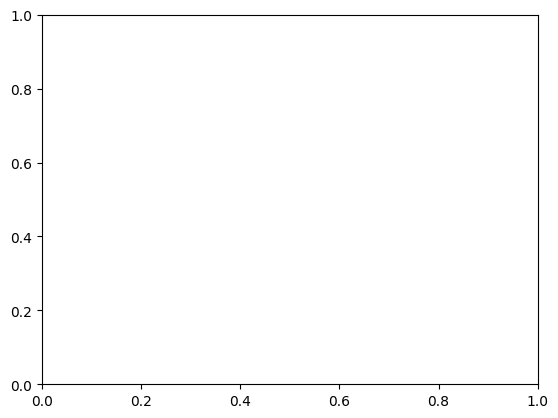

In [151]:
values = np.array([ludics.main.fermi_imitation_function(delta=-alpha, choice_intensity=0.5) for alpha in range(1,20)])
print(values)
sns.lineplot(x = np.array(range(1,20)), y = values)
plt.show()

In [159]:
source1 = np.array([1,1,0,0])
target1 = np.array([1,1,1,0])
target2 = np.array([1,0,0,0])

In [157]:
different_indices = np.where(source1 != target2)
fitness = ludics.fitness_functions.heterogeneous_contribution_pgg_fitness_function(source1, r=1.5, contribution_vector=np.array([1,1,1,1]))

changes = [
        ludics.main.fermi_imitation_function(
            delta=fitness[different_indices] - fitness[i],
            choice_intensity=0.5,
        )
        for i in np.where(source1 == target1[different_indices])
    ]
changes

[array([1/2, 1/2], dtype=object)]

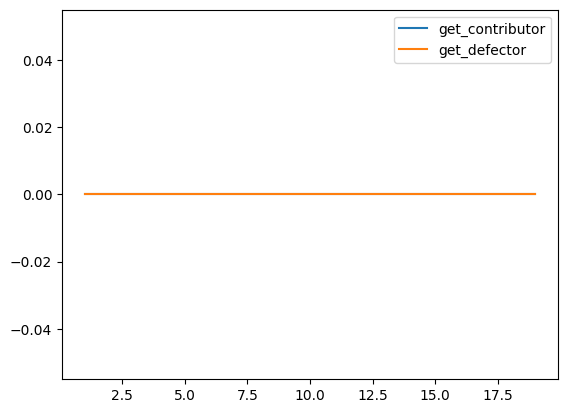

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [167]:
values1 = np.array([int(ludics.main.compute_fermi_transition_probability(
    source=source1,
    target=target1,
    fitness_function=ludics.fitness_functions.heterogeneous_contribution_pgg_fitness_function,
    choice_intensity=0.5,
    r=1.8,
    contribution_vector = np.array([alpha * i for i in range(4)])
)) for alpha in range(1,20)])

values2 = np.array([int(ludics.main.compute_fermi_transition_probability(
    source=source1,
    target=target2,
    fitness_function=ludics.fitness_functions.homogeneous_pgg_fitness_function,
    choice_intensity=0.5,
    r=1.5,
    alpha=alpha
)) for alpha in range(1,20)])


sns.lineplot(x=np.array([_ for _ in range(1,20)]), y=values1, label='get_contributor')
sns.lineplot(x=range(1,20), y=values2, label='get_defector')

plt.legend()
plt.show()

print(values1)